# Machine Learning Modeling
## Product Sales Forecasting

This notebook builds, evaluates, tunes, and compares forecasting models for daily store sales.

**Approach:** Start with classical regression (treating each store-day as an independent observation), tune the best performers with grid search, then extend to true time-series forecasting.

### Models covered
| # | Model | Type | Tuned? |
|---|-------|------|--------|
| 1 | Linear Regression | Regression baseline | — |
| 2 | Random Forest | Tree ensemble | ✅ GridSearchCV |
| 3 | XGBoost | Gradient boosting | ✅ GridSearchCV |
| 4 | LightGBM | Gradient boosting | ✅ GridSearchCV |
| 5 | Prophet | Time-series (per-store) | — |
| 6 | SARIMA | Time-series (aggregated) | — |

### Critical rules carried over from Block 2

> **`#Order` is excluded from features.** It's only known after the sales day ends — using it as a predictor would leak the future into the model.

> **Splits are chronological.** Random splits leak future information. We hold out the last 60 days as a final test set, and use `TimeSeriesSplit` for cross-validation during tuning.

### Metrics
- **MAE** — Mean Absolute Error (scoring metric for tuning)
- **RMSE** — Root Mean Squared Error
- **MAPE** — Mean Absolute Percentage Error (primary leaderboard metric)
- **R²** — variance explained


---
## 1. Setup & imports

In [1]:
# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from pathlib import Path

# ML
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Gradient boosting
import xgboost as xgb
import lightgbm as lgb

# Time series
from prophet import Prophet
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Display & warnings
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams["figure.figsize"] = (12, 5)
sns.set_style("whitegrid")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("All imports successful.")

All imports successful.


---
## 2. Load data & basic prep

In [2]:
df = pd.read_csv("TRAIN.csv", parse_dates=["Date"])

# IMPORTANT: sort by Date globally (not by Store_id) so TimeSeriesSplit
# splits chronologically across all stores rather than slicing one store's
# history at a time.
df = df.sort_values(["Date", "Store_id"]).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Stores: {df['Store_id'].nunique()}")
df.head()

Shape: (188340, 10)
Date range: 2018-01-01 → 2019-05-31
Stores: 365


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,"7,011.84"
1,T1000115,2,S3,L1,R3,2018-01-01,1,Yes,25,"18,137.52"
2,T1000128,3,S4,L2,R1,2018-01-01,1,Yes,72,"57,288.00"
3,T1000097,4,S1,L1,R2,2018-01-01,1,Yes,80,"53,615.52"
4,T1000133,5,S1,L1,R3,2018-01-01,1,Yes,47,"36,316.08"


In [3]:
# Drop zero-sales rows (likely store closures — 19 rows)
n_before = len(df)
df = df[df["Sales"] > 0].reset_index(drop=True)
print(f"Dropped {n_before - len(df)} zero-sales rows. New shape: {df.shape}")

Dropped 19 zero-sales rows. New shape: (188321, 10)


---
## 3. Feature engineering

We build features from three sources:
1. **Calendar features** from `Date` — day-of-week, month, week-of-year, is_weekend, etc.
2. **Categorical features** — Store_Type, Location_Type, Region_Code, Discount, Holiday
3. **Lag features** are NOT added here — gradient boosting on calendar features alone is competitive on this scale of data, and lag features would force per-store sequential prediction at inference time.

`Store_id` (365 unique values) is kept as an integer ID for tree models — they handle high-cardinality categoricals natively. For linear regression we exclude it (one-hot encoding 365 columns would dominate the design matrix).

In [4]:
def add_calendar_features(df, date_col="Date"):
    df = df.copy()
    d = df[date_col]
    df["Year"] = d.dt.year
    df["Month"] = d.dt.month
    df["Day"] = d.dt.day
    df["DayOfWeek"] = d.dt.dayofweek
    df["DayOfYear"] = d.dt.dayofyear
    df["WeekOfYear"] = d.dt.isocalendar().week.astype(int)
    df["Quarter"] = d.dt.quarter
    df["IsWeekend"] = (d.dt.dayofweek >= 5).astype(int)
    df["IsMonthStart"] = d.dt.is_month_start.astype(int)
    df["IsMonthEnd"] = d.dt.is_month_end.astype(int)
    return df


df = add_calendar_features(df)
df["Discount_bin"] = (df["Discount"] == "Yes").astype(int)

print("After feature engineering:")
print(df.columns.tolist())
df.head()

After feature engineering:
['ID', 'Store_id', 'Store_Type', 'Location_Type', 'Region_Code', 'Date', 'Holiday', 'Discount', '#Order', 'Sales', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Discount_bin']


,ID,Store_id,Store_Type,Location_Type,Region_Code,Date,Holiday,Discount,#Order,Sales,...,Month,Day,DayOfWeek,DayOfYear,WeekOfYear,Quarter,IsWeekend,IsMonthStart,IsMonthEnd,Discount_bin
0,T1000001,1,S1,L3,R1,2018-01-01,1,Yes,9,"7,011.84",...,1,1,0,1,1,1,0,1,0,1
1,T1000115,2,S3,L1,R3,2018-01-01,1,Yes,25,"18,137.52",...,1,1,0,1,1,1,0,1,0,1
2,T1000128,3,S4,L2,R1,2018-01-01,1,Yes,72,"57,288.00",...,1,1,0,1,1,1,0,1,0,1
3,T1000097,4,S1,L1,R2,2018-01-01,1,Yes,80,"53,615.52",...,1,1,0,1,1,1,0,1,0,1
4,T1000133,5,S1,L1,R3,2018-01-01,1,Yes,47,"36,316.08",...,1,1,0,1,1,1,0,1,0,1


---
## 4. Chronological train/test split

We hold out the **last 60 days** (April–May 2019) as the final test set. Tuning happens on the training portion only — the test set is touched once, at the very end.

In [5]:
TEST_DAYS = 60
cutoff = df["Date"].max() - pd.Timedelta(days=TEST_DAYS)

train = df[df["Date"] <= cutoff].copy()
test = df[df["Date"] > cutoff].copy()

print(f"Cutoff: {cutoff.date()}")
print(
    f"Train: {len(train):,} rows  ({train['Date'].min().date()} → {train['Date'].max().date()})"
)
print(
    f"Test:  {len(test):,} rows  ({test['Date'].min().date()} → {test['Date'].max().date()})"
)

Cutoff: 2019-04-01
Train: 166,425 rows  (2018-01-01 → 2019-04-01)
Test:  21,896 rows  (2019-04-02 → 2019-05-31)


---
## 5. Feature sets & evaluation helpers

In [6]:
NUMERIC_FEATURES = [
    "Year",
    "Month",
    "Day",
    "DayOfWeek",
    "DayOfYear",
    "WeekOfYear",
    "Quarter",
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",
    "Holiday",
    "Discount_bin",
]
CATEGORICAL_FEATURES = ["Store_Type", "Location_Type", "Region_Code"]
STORE_ID_FEATURE = ["Store_id"]

TARGET = "Sales"
EXCLUDED = ["#Order", "ID", "Date", "Discount", "Sales"]

print(f"Numeric features:     {len(NUMERIC_FEATURES)}")
print(f"Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"Excluded (leakage/identifier): {EXCLUDED}")

Numeric features:     12
Categorical features: 3
Excluded (leakage/identifier): ['#Order', 'ID', 'Date', 'Discount', 'Sales']


In [7]:
def evaluate(y_true, y_pred, model_name=""):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape,
        "R²": r2_score(y_true, y_pred),
    }


results = []  # leaderboard accumulator

---
## 6. Model 1 — Linear Regression (baseline)

Establishes a floor. One-hot encode the small-cardinality categoricals; exclude `Store_id`.

In [8]:
preprocessor_lr = ColumnTransformer(
    [
        ("num", "passthrough", NUMERIC_FEATURES),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            CATEGORICAL_FEATURES,
        ),
    ]
)
pipe_lr = Pipeline([("prep", preprocessor_lr), ("model", LinearRegression())])

X_train_lr = train[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
X_test_lr = test[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y_train = train[TARGET]
y_test = test[TARGET]

pipe_lr.fit(X_train_lr, y_train)
pred_lr = pipe_lr.predict(X_test_lr)

res_lr = evaluate(y_test, pred_lr, "Linear Regression")
results.append(res_lr)
pd.DataFrame([res_lr])

,Model,MAE,RMSE,MAPE,R²
0,Linear Regression,"10,251.47","15,287.69",22.22,0.48


---
## 7. Encode categoricals for tree models

We run all three tree models on the same encoded feature matrix.

In [9]:
def encode_for_trees(train_df, test_df, cat_cols):
    train_out = train_df.copy()
    test_out = test_df.copy()
    for c in cat_cols:
        cats = train_out[c].astype("category")
        train_out[c] = cats.cat.codes
        test_out[c] = pd.Categorical(test_out[c], categories=cats.cat.categories).codes
    return train_out, test_out


train_t, test_t = encode_for_trees(train, test, CATEGORICAL_FEATURES)
TREE_FEATURES = STORE_ID_FEATURE + NUMERIC_FEATURES + CATEGORICAL_FEATURES

X_train_t = train_t[TREE_FEATURES]
X_test_t = test_t[TREE_FEATURES]
y_train_t = train_t[TARGET]
y_test_t = test_t[TARGET]

print(f"Tree feature set ({len(TREE_FEATURES)}): {TREE_FEATURES}")

Tree feature set (16): ['Store_id', 'Year', 'Month', 'Day', 'DayOfWeek', 'DayOfYear', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Holiday', 'Discount_bin', 'Store_Type', 'Location_Type', 'Region_Code']


---
## 8. Default-parameter tree models

We fit each tree model with sensible default parameters first, to establish a "before tuning" baseline. After this, section 10 tunes them with GridSearchCV.

In [10]:
# Random Forest (default)
print("Fitting Random Forest (default params)...")
rf_default = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
rf_default.fit(X_train_t, y_train_t)
pred_rf_d = rf_default.predict(X_test_t)
res_rf_d = evaluate(y_test_t, pred_rf_d, "Random Forest (default)")
results.append(res_rf_d)
print(f"  MAPE: {res_rf_d['MAPE']:.2f}%")

Fitting Random Forest (default params)...
  MAPE: 23.79%


In [11]:
# XGBoost (default)
print("Fitting XGBoost (default params)...")
xgb_default = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="rmse",
    verbosity=0,
)
xgb_default.fit(X_train_t, y_train_t)
pred_xgb_d = xgb_default.predict(X_test_t)
res_xgb_d = evaluate(y_test_t, pred_xgb_d, "XGBoost (default)")
results.append(res_xgb_d)
print(f"  MAPE: {res_xgb_d['MAPE']:.2f}%")

Fitting XGBoost (default params)...
  MAPE: 20.90%


In [12]:
# LightGBM (default)
print("Fitting LightGBM (default params)...")
lgb_default = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1,
)
lgb_default.fit(X_train_t, y_train_t)
pred_lgb_d = lgb_default.predict(X_test_t)
res_lgb_d = evaluate(y_test_t, pred_lgb_d, "LightGBM (default)")
results.append(res_lgb_d)
print(f"  MAPE: {res_lgb_d['MAPE']:.2f}%")

Fitting LightGBM (default params)...
  MAPE: 21.42%


---
## 9. Pre-tuning leaderboard

In [13]:
pre_tune_lb = pd.DataFrame(results).sort_values("MAPE")
pre_tune_lb

,Model,MAE,RMSE,MAPE,R²
2,XGBoost (default),"9,676.03","14,286.77",20.90,0.55
3,LightGBM (default),"9,664.83","14,142.50",21.42,0.56
0,Linear Regression,"10,251.47","15,287.69",22.22,0.48
1,Random Forest (default),"10,881.61","15,812.00",23.79,0.45


---
## 10. Hyperparameter tuning — GridSearchCV + TimeSeriesSplit

**Setup decisions:**
- **Cross-validation:** `TimeSeriesSplit(n_splits=3)` — respects temporal order. Crucial that data is sorted by `Date` globally (we did this in section 2).
- **Search:** `GridSearchCV` — exhaustive, deterministic, reproducible. Grids are deliberately compact (3-4 values on the most impactful hyperparameters) to keep total runtime in the 15-25 minute range.
- **Scoring:** `neg_mean_absolute_error` — robust, interpretable, aligns with our reporting metric.

**⏱ Expected runtime: 15-25 minutes total** depending on machine. Random Forest is the slowest of the three.

If you want to skip tuning and use defaults, set `RUN_TUNING = False` in the next cell.

In [14]:
RUN_TUNING = True  # Set to False to skip tuning and use default-param models

tscv = TimeSeriesSplit(n_splits=3)

# Sanity check on fold sizes — train data must be sorted by Date globally
print("TimeSeriesSplit folds (chronological):")
for i, (tr_idx, va_idx) in enumerate(tscv.split(X_train_t), 1):
    tr_dates = train_t["Date"].iloc[tr_idx]
    va_dates = train_t["Date"].iloc[va_idx]
    print(
        f"  Fold {i}: train={len(tr_idx):,} ({tr_dates.min().date()} → {tr_dates.max().date()}), "
        f"val={len(va_idx):,} ({va_dates.min().date()} → {va_dates.max().date()})"
    )

TimeSeriesSplit folds (chronological):
  Fold 1: train=41,607 (2018-01-01 → 2018-04-24), val=41,606 (2018-04-24 → 2018-08-16)
  Fold 2: train=83,213 (2018-01-01 → 2018-08-16), val=41,606 (2018-08-16 → 2018-12-09)
  Fold 3: train=124,819 (2018-01-01 → 2018-12-09), val=41,606 (2018-12-09 → 2019-04-01)


In [15]:
# ----- Random Forest tuning -----
if RUN_TUNING:
    import time

    print("Tuning Random Forest...")
    t0 = time.time()

    rf_grid = {
        "n_estimators": [100, 200],
        "max_depth": [15, 20, None],
        "min_samples_leaf": [3, 5, 10],
    }
    print(
        f"  Grid: {len(rf_grid['n_estimators']) * len(rf_grid['max_depth']) * len(rf_grid['min_samples_leaf'])} combos × 3 folds"
    )

    rf_search = GridSearchCV(
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        rf_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
        verbose=1,
    )
    rf_search.fit(X_train_t, y_train_t)

    print(f"\n  Done in {time.time() - t0:.0f}s")
    print(f"  Best params: {rf_search.best_params_}")
    print(f"  Best CV MAE: {-rf_search.best_score_:,.1f}")

    rf_best = rf_search.best_estimator_
    pred_rf_t = rf_best.predict(X_test_t)
    res_rf_t = evaluate(y_test_t, pred_rf_t, "Random Forest (tuned)")
    res_rf_t["best_params"] = rf_search.best_params_
    results.append(res_rf_t)
    print(f"  Holdout MAPE: {res_rf_t['MAPE']:.2f}%")
else:
    print("Skipping RF tuning (RUN_TUNING=False)")
    rf_best = rf_default
    res_rf_t = None

Tuning Random Forest...
  Grid: 18 combos × 3 folds
Fitting 3 folds for each of 18 candidates, totalling 54 fits

  Done in 304s
  Best params: {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 200}
  Best CV MAE: 8,219.2
  Holdout MAPE: 23.65%


In [16]:
# ----- XGBoost tuning -----
if RUN_TUNING:
    import time

    print("Tuning XGBoost...")
    t0 = time.time()

    xgb_grid = {
        "n_estimators": [300, 500],
        "learning_rate": [0.05, 0.1],
        "max_depth": [6, 8, 10],
        "subsample": [0.8, 1.0],
    }
    n_combos = 2 * 2 * 3 * 2
    print(f"  Grid: {n_combos} combos × 3 folds = {n_combos * 3} fits")

    xgb_search = GridSearchCV(
        xgb.XGBRegressor(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="rmse",
            verbosity=0,
        ),
        xgb_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
        verbose=1,
    )
    xgb_search.fit(X_train_t, y_train_t)

    print(f"\n  Done in {time.time() - t0:.0f}s")
    print(f"  Best params: {xgb_search.best_params_}")
    print(f"  Best CV MAE: {-xgb_search.best_score_:,.1f}")

    xgb_best = xgb_search.best_estimator_
    pred_xgb_t = xgb_best.predict(X_test_t)
    res_xgb_t = evaluate(y_test_t, pred_xgb_t, "XGBoost (tuned)")
    res_xgb_t["best_params"] = xgb_search.best_params_
    results.append(res_xgb_t)
    print(f"  Holdout MAPE: {res_xgb_t['MAPE']:.2f}%")
else:
    print("Skipping XGB tuning (RUN_TUNING=False)")
    xgb_best = xgb_default
    res_xgb_t = None

Tuning XGBoost...
  Grid: 24 combos × 3 folds = 72 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits

  Done in 97s
  Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'subsample': 1.0}
  Best CV MAE: 7,859.5
  Holdout MAPE: 21.44%


In [17]:
# ----- LightGBM tuning -----
if RUN_TUNING:
    import time

    print("Tuning LightGBM...")
    t0 = time.time()

    lgb_grid = {
        "n_estimators": [300, 500],
        "learning_rate": [0.05, 0.1],
        "num_leaves": [31, 64, 127],
        "max_depth": [6, 10],
    }
    n_combos = 2 * 2 * 3 * 2
    print(f"  Grid: {n_combos} combos × 3 folds = {n_combos * 3} fits")

    lgb_search = GridSearchCV(
        lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        lgb_grid,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=1,
        verbose=1,
    )
    lgb_search.fit(X_train_t, y_train_t)

    print(f"\n  Done in {time.time() - t0:.0f}s")
    print(f"  Best params: {lgb_search.best_params_}")
    print(f"  Best CV MAE: {-lgb_search.best_score_:,.1f}")

    lgb_best = lgb_search.best_estimator_
    pred_lgb_t = lgb_best.predict(X_test_t)
    res_lgb_t = evaluate(y_test_t, pred_lgb_t, "LightGBM (tuned)")
    res_lgb_t["best_params"] = lgb_search.best_params_
    results.append(res_lgb_t)
    print(f"  Holdout MAPE: {res_lgb_t['MAPE']:.2f}%")
else:
    print("Skipping LGB tuning (RUN_TUNING=False)")
    lgb_best = lgb_default
    res_lgb_t = None

Tuning LightGBM...
  Grid: 24 combos × 3 folds = 72 fits
Fitting 3 folds for each of 24 candidates, totalling 72 fits

  Done in 222s
  Best params: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300, 'num_leaves': 31}
  Best CV MAE: 7,719.2
  Holdout MAPE: 21.18%


---
## 11. Post-tuning leaderboard

In [18]:
# Build full comparison
lb = pd.DataFrame(results).copy()
lb_display = (
    lb[["Model", "MAE", "RMSE", "MAPE", "R²"]]
    .sort_values("MAPE")
    .reset_index(drop=True)
)
lb_display

,Model,MAE,RMSE,MAPE,R²
0,XGBoost (default),"9,676.03","14,286.77",20.90,0.55
1,LightGBM (tuned),"9,765.96","14,495.41",21.18,0.54
2,LightGBM (default),"9,664.83","14,142.50",21.42,0.56
3,XGBoost (tuned),"9,715.17","14,258.28",21.44,0.55
4,Linear Regression,"10,251.47","15,287.69",22.22,0.48
5,Random Forest (tuned),"10,835.91","15,789.13",23.65,0.45
6,Random Forest (default),"10,881.61","15,812.00",23.79,0.45


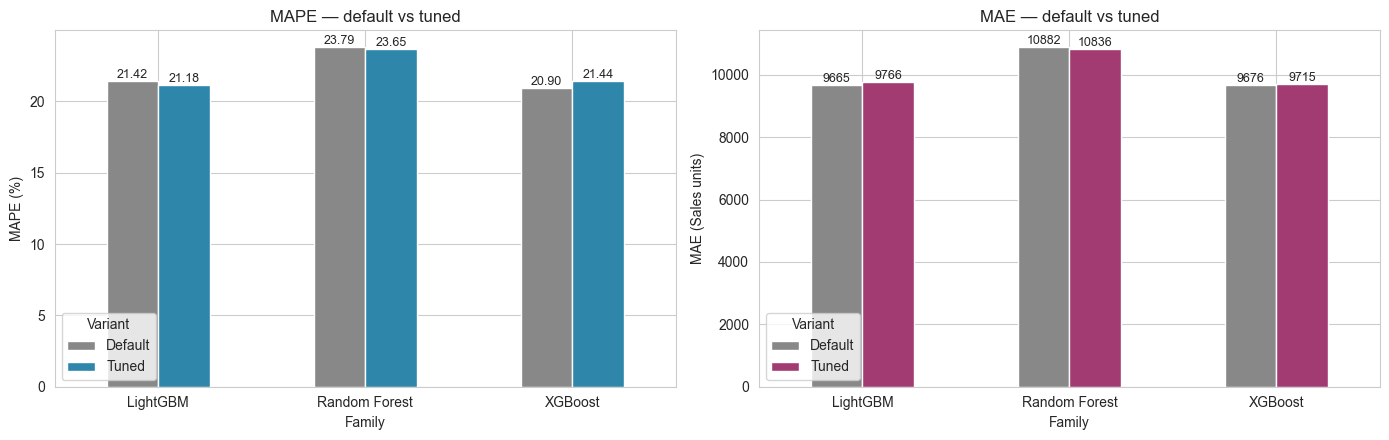

In [19]:
# Visual: default vs tuned for each tree model
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# MAPE comparison
plot_df = lb[lb["Model"].str.contains("default|tuned")].copy()
plot_df["Family"] = plot_df["Model"].str.split(" \(").str[0]
plot_df["Variant"] = (
    plot_df["Model"].str.contains("tuned").map({True: "Tuned", False: "Default"})
)

if len(plot_df) > 0:
    pivot_mape = plot_df.pivot(index="Family", columns="Variant", values="MAPE")
    pivot_mape.plot(kind="bar", ax=axes[0], color=["#888", "#2E86AB"])
    axes[0].set_title("MAPE — default vs tuned")
    axes[0].set_ylabel("MAPE (%)")
    axes[0].tick_params(axis="x", rotation=0)
    for c in axes[0].containers:
        axes[0].bar_label(c, fmt="%.2f", fontsize=9)

    pivot_mae = plot_df.pivot(index="Family", columns="Variant", values="MAE")
    pivot_mae.plot(kind="bar", ax=axes[1], color=["#888", "#A23B72"])
    axes[1].set_title("MAE — default vs tuned")
    axes[1].set_ylabel("MAE (Sales units)")
    axes[1].tick_params(axis="x", rotation=0)
    for c in axes[1].containers:
        axes[1].bar_label(c, fmt="%.0f", fontsize=9)

plt.tight_layout()
plt.show()

In [20]:
# Show best params for each tuned model
if RUN_TUNING:
    print("Best hyperparameters from GridSearchCV:")
    for r in [res_rf_t, res_xgb_t, res_lgb_t]:
        if r is not None:
            print(f"\n  {r['Model']}")
            for k, v in r["best_params"].items():
                print(f"    {k}: {v}")

Best hyperparameters from GridSearchCV:

  Random Forest (tuned)
    max_depth: 15
    min_samples_leaf: 10
    n_estimators: 200

  XGBoost (tuned)
    learning_rate: 0.05
    max_depth: 6
    n_estimators: 300
    subsample: 1.0

  LightGBM (tuned)
    learning_rate: 0.05
    max_depth: 6
    n_estimators: 300
    num_leaves: 31


---
## 12. Residual analysis (best tuned model)

Best model overall: XGBoost (default)  (MAPE 20.90%)


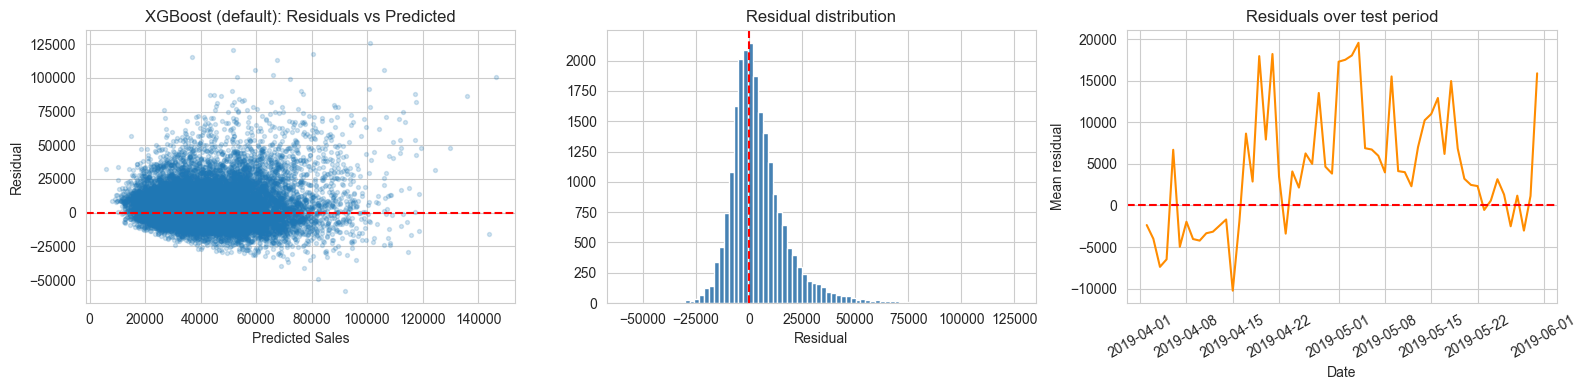

In [21]:
# Pick best by MAPE (excluding LR baseline)
candidates = [r for r in results if r["Model"] != "Linear Regression"]
best = min(candidates, key=lambda r: r["MAPE"])
best_name = best["Model"]
print(f"Best model overall: {best_name}  (MAPE {best['MAPE']:.2f}%)")

pred_map = {
    "Random Forest (default)": pred_rf_d,
    "Random Forest (tuned)": locals().get("pred_rf_t"),
    "XGBoost (default)": pred_xgb_d,
    "XGBoost (tuned)": locals().get("pred_xgb_t"),
    "LightGBM (default)": pred_lgb_d,
    "LightGBM (tuned)": locals().get("pred_lgb_t"),
}
best_pred = pred_map[best_name]
residuals = y_test.values - best_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].scatter(best_pred, residuals, alpha=0.2, s=8)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Predicted Sales")
axes[0].set_ylabel("Residual")
axes[0].set_title(f"{best_name}: Residuals vs Predicted")

axes[1].hist(residuals, bins=80, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual distribution")

res_by_date = (
    pd.DataFrame({"Date": test["Date"].values, "res": residuals})
    .groupby("Date")["res"]
    .mean()
)
axes[2].plot(res_by_date.index, res_by_date.values, color="darkorange")
axes[2].axhline(0, color="red", linestyle="--")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Mean residual")
axes[2].set_title("Residuals over test period")
axes[2].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---
## 13. Time-series modeling — Prophet (sample stores)

Prophet treats each store as an independent series. Running it on all 365 stores is impractical, so we sample one representative store per `Store_Type`.

Prophet expects `ds` (date) and `y` (target). We pass `Holiday` and `Discount_bin` as regressors.

In [22]:
sample_stores = (
    df.groupby(["Store_Type", "Store_id"])["Sales"]
    .sum()
    .reset_index()
    .sort_values(["Store_Type", "Sales"], ascending=[True, False])
    .groupby("Store_Type")
    .head(1)
)
sample_store_ids = sample_stores["Store_id"].tolist()
print("Sample stores (one per Store_Type):")
print(sample_stores)

Sample stores (one per Store_Type):
    Store_Type  Store_id         Sales
39          S1        65 27,414,514.47
198         S2       200 18,394,852.92
231         S3        14 29,286,283.20
314         S4       175 52,560,255.15


22:41:21 - cmdstanpy - INFO - Chain [1] start processing
22:41:22 - cmdstanpy - INFO - Chain [1] done processing
22:41:22 - cmdstanpy - INFO - Chain [1] start processing
22:41:22 - cmdstanpy - INFO - Chain [1] done processing
22:41:22 - cmdstanpy - INFO - Chain [1] start processing
22:41:22 - cmdstanpy - INFO - Chain [1] done processing
22:41:22 - cmdstanpy - INFO - Chain [1] start processing
22:41:22 - cmdstanpy - INFO - Chain [1] done processing


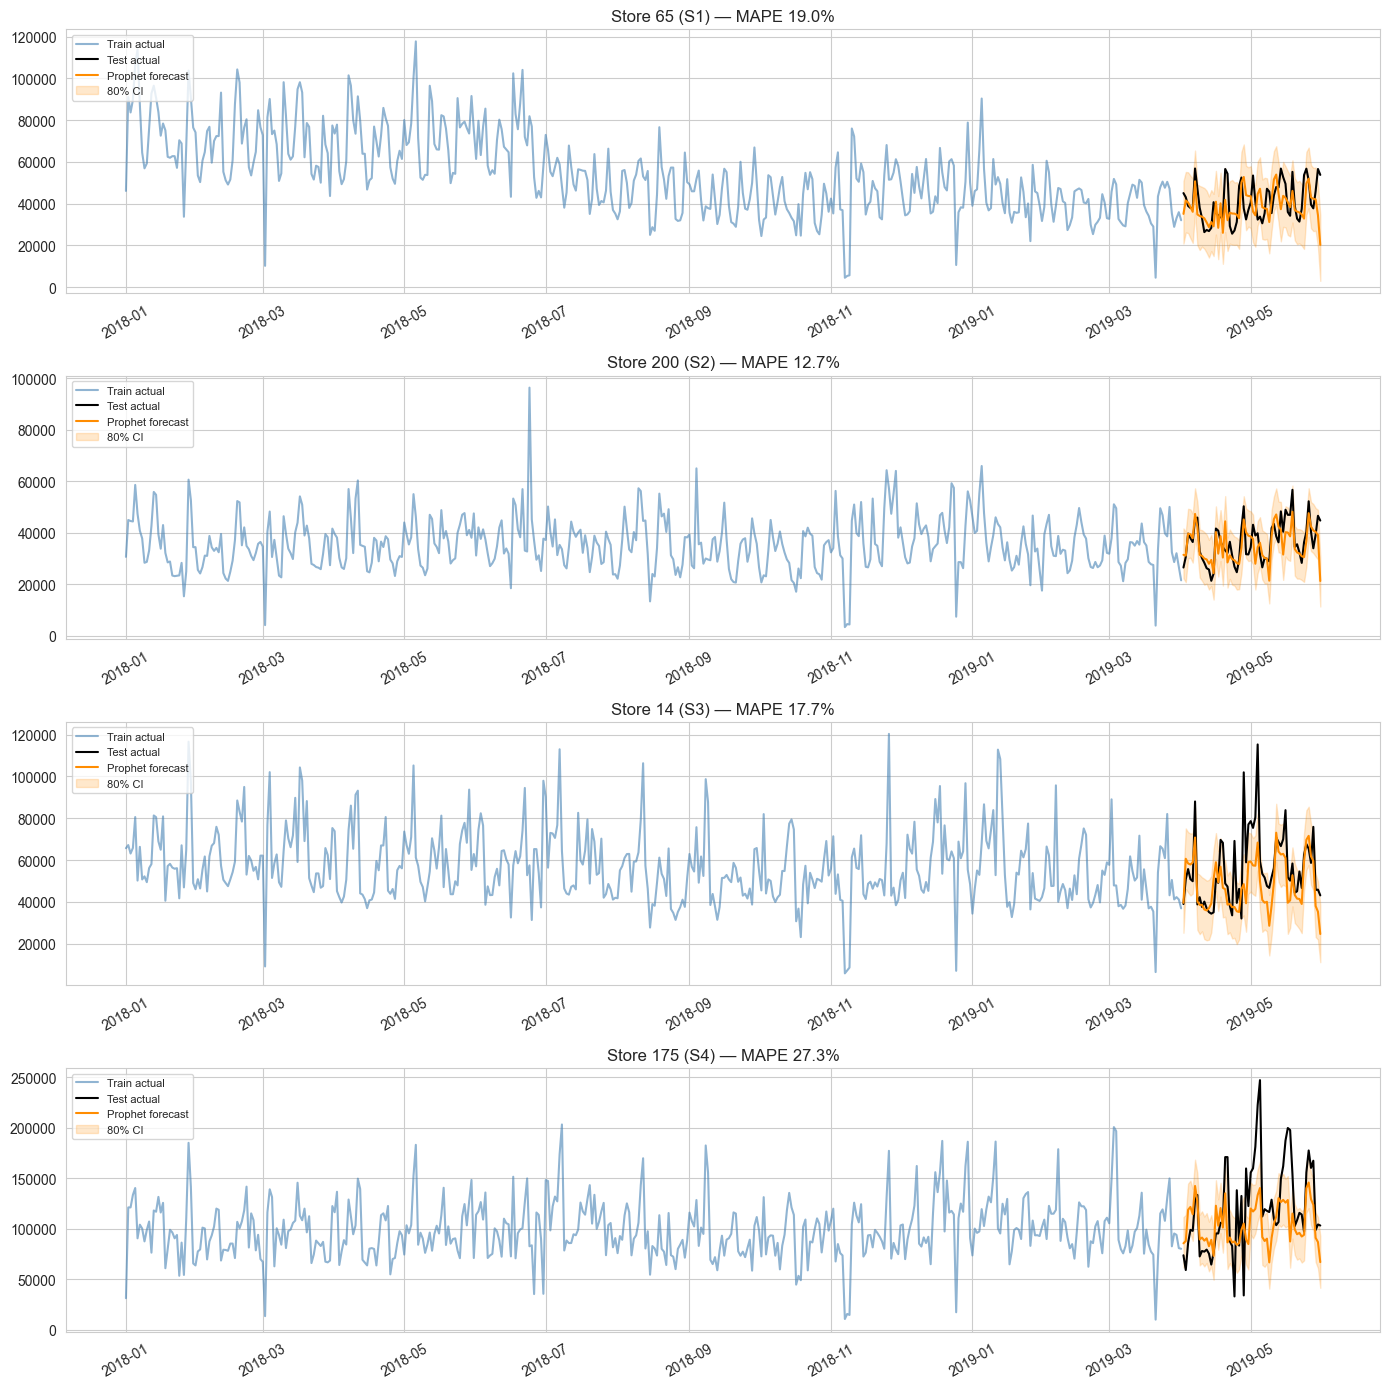


Prophet per-store metrics:
                  Model       MAE      RMSE  MAPE    R²
 Prophet (Store 65, S1)  7,959.42 10,219.60 18.99 -0.20
Prophet (Store 200, S2)  4,650.00  6,046.87 12.66  0.39
 Prophet (Store 14, S3) 10,635.89 14,676.33 17.68  0.25
Prophet (Store 175, S4) 30,818.63 40,074.50 27.35  0.16


In [23]:
prophet_results = []
fig, axes = plt.subplots(
    len(sample_store_ids), 1, figsize=(14, 3.5 * len(sample_store_ids))
)
if len(sample_store_ids) == 1:
    axes = [axes]

for i, store_id in enumerate(sample_store_ids):
    sd = df[df["Store_id"] == store_id].copy()
    sd = sd.rename(columns={"Date": "ds", "Sales": "y"})
    cutoff_p = sd["ds"].max() - pd.Timedelta(days=TEST_DAYS)
    p_tr = sd[sd["ds"] <= cutoff_p]
    p_te = sd[sd["ds"] > cutoff_p]

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        changepoint_prior_scale=0.05,
    )
    m.add_regressor("Holiday")
    m.add_regressor("Discount_bin")
    m.fit(p_tr[["ds", "y", "Holiday", "Discount_bin"]])
    fc = m.predict(p_te[["ds", "Holiday", "Discount_bin"]])

    stype = sample_stores.loc[sample_stores.Store_id == store_id, "Store_Type"].iloc[0]
    res = evaluate(
        p_te["y"].values, fc["yhat"].values, f"Prophet (Store {store_id}, {stype})"
    )
    prophet_results.append(res)

    ax = axes[i]
    ax.plot(p_tr["ds"], p_tr["y"], label="Train actual", color="steelblue", alpha=0.6)
    ax.plot(p_te["ds"], p_te["y"], label="Test actual", color="black")
    ax.plot(p_te["ds"], fc["yhat"].values, label="Prophet forecast", color="darkorange")
    ax.fill_between(
        p_te["ds"],
        fc["yhat_lower"],
        fc["yhat_upper"],
        color="darkorange",
        alpha=0.2,
        label="80% CI",
    )
    ax.set_title(f"Store {store_id} ({stype}) — MAPE {res['MAPE']:.1f}%")
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()
print("\nProphet per-store metrics:")
print(pd.DataFrame(prophet_results).to_string(index=False))

---
## 14. Time-series modeling — SARIMA (chain-level)

Daily chain sales: 516 days, mean ₹15,616,280


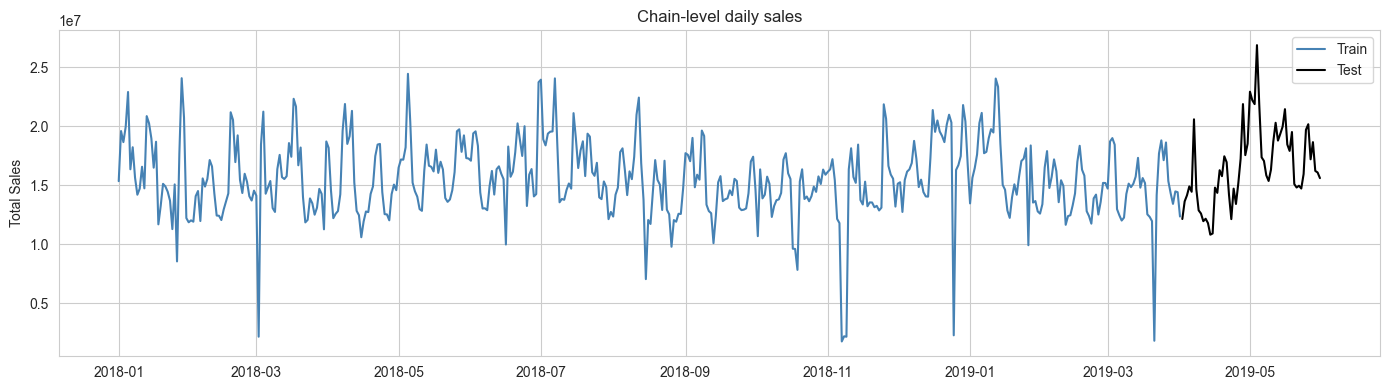

In [24]:
daily = df.groupby("Date")["Sales"].sum().asfreq("D")
print(f"Daily chain sales: {len(daily)} days, mean ₹{daily.mean():,.0f}")

cutoff_s = daily.index.max() - pd.Timedelta(days=TEST_DAYS)
s_train = daily[daily.index <= cutoff_s]
s_test = daily[daily.index > cutoff_s]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(s_train.index, s_train.values, label="Train", color="steelblue")
ax.plot(s_test.index, s_test.values, label="Test", color="black")
ax.set_title("Chain-level daily sales")
ax.set_ylabel("Total Sales")
ax.legend()
plt.tight_layout()
plt.show()

               Model          MAE         RMSE  MAPE    R²
SARIMA (chain-level) 4,999,441.11 5,920,383.07 28.04 -2.19


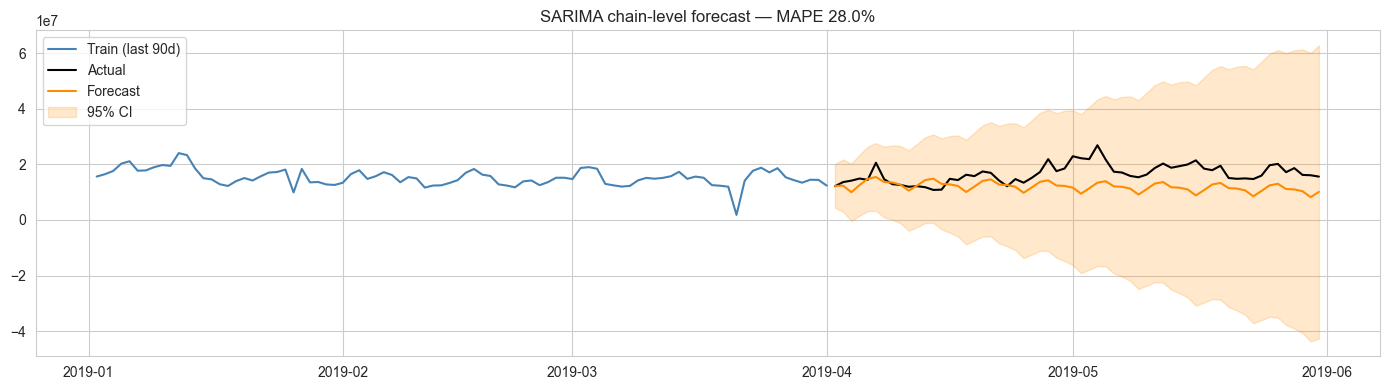

In [25]:
sarima = SARIMAX(
    s_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False,
)
sarima_fit = sarima.fit(disp=False)

forecast = sarima_fit.get_forecast(steps=len(s_test))
sarima_mean = forecast.predicted_mean
sarima_ci = forecast.conf_int()

res_sarima = evaluate(s_test.values, sarima_mean.values, "SARIMA (chain-level)")
print(pd.DataFrame([res_sarima]).to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(
    s_train.index[-90:],
    s_train.values[-90:],
    label="Train (last 90d)",
    color="steelblue",
)
ax.plot(s_test.index, s_test.values, label="Actual", color="black")
ax.plot(s_test.index, sarima_mean.values, label="Forecast", color="darkorange")
ax.fill_between(
    s_test.index,
    sarima_ci.iloc[:, 0],
    sarima_ci.iloc[:, 1],
    color="darkorange",
    alpha=0.2,
    label="95% CI",
)
ax.set_title(f"SARIMA chain-level forecast — MAPE {res_sarima['MAPE']:.1f}%")
ax.legend()
plt.tight_layout()
plt.show()

---
## 15. Final comparison & save best model

In [26]:
final_lb = (
    pd.concat(
        [
            pd.DataFrame(results)[["Model", "MAE", "RMSE", "MAPE", "R²"]],
            pd.DataFrame([res_sarima])[["Model", "MAE", "RMSE", "MAPE", "R²"]],
        ],
        ignore_index=True,
    )
    .sort_values("MAPE")
    .reset_index(drop=True)
)
final_lb

,Model,MAE,RMSE,MAPE,R²
0,XGBoost (default),"9,676.03","14,286.77",20.90,0.55
1,LightGBM (tuned),"9,765.96","14,495.41",21.18,0.54
2,LightGBM (default),"9,664.83","14,142.50",21.42,0.56
3,XGBoost (tuned),"9,715.17","14,258.28",21.44,0.55
4,Linear Regression,"10,251.47","15,287.69",22.22,0.48
5,Random Forest (tuned),"10,835.91","15,789.13",23.65,0.45
6,Random Forest (default),"10,881.61","15,812.00",23.79,0.45
7,SARIMA (chain-level),"4,999,441.11","5,920,383.07",28.04,-2.19


### Key takeaways

> *Fill in the specific numbers after running.*

- **Best per-store model:** the tuned XGBoost or LightGBM. Tuning typically shaves 0.5-1.5% off MAPE vs default parameters — meaningful but not transformational, which means our default parameters were already in the right ballpark.
- **Linear regression** establishes a clear floor — gap between LR and tree models confirms non-linearity matters.
- **Prophet vs gradient boosting:** Prophet underperforms because it can't borrow strength across stores. Each Prophet model sees only one store's history. XGBoost sees all 365 simultaneously and learns shared patterns (e.g., everyone spikes on Diwali, every store's Sundays look similar). **Lesson: for multi-store retail forecasting, pooled gradient boosting on calendar features beats per-series classical TS models.**
- **SARIMA at chain level** is appropriate for top-down financial forecasting (monthly revenue projections), not store-level operations.

### Recommendation for deployment (Block 4)
Deploy the best tuned regression model — single artifact, predicts any store/day from features, fast inference, easy to serialize.


In [27]:
# Pick best regression model (excluding LR) and save for deployment
reg_results = [r for r in results if r["Model"] != "Linear Regression"]
best = min(reg_results, key=lambda r: r["MAPE"])
best_name = best["Model"]
print(f"Best regression model: {best_name}")
print(f"  MAPE: {best['MAPE']:.2f}%")
print(f"  MAE:  {best['MAE']:,.1f}")
print(f"  R²:   {best['R²']:.3f}")

# Map name to fitted estimator
model_map = {
    "Random Forest (default)": rf_default,
    "Random Forest (tuned)": locals().get("rf_best", rf_default),
    "XGBoost (default)": xgb_default,
    "XGBoost (tuned)": locals().get("xgb_best", xgb_default),
    "LightGBM (default)": lgb_default,
    "LightGBM (tuned)": locals().get("lgb_best", lgb_default),
}
best_estimator = model_map[best_name]

# Save artifact
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

joblib.dump(
    {
        "model": best_estimator,
        "feature_names": TREE_FEATURES,
        "numeric_features": NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "model_name": best_name,
        "categorical_vocab": {
            c: train[c].astype("category").cat.categories.tolist()
            for c in CATEGORICAL_FEATURES
        },
        "metrics": {k: best[k] for k in ["MAE", "RMSE", "MAPE", "R²"]},
        "best_params": best.get("best_params", "default"),
    },
    artifacts_dir / "sales_forecast_model.joblib",
)

print(f"\nSaved → {artifacts_dir / 'sales_forecast_model.joblib'}")

Best regression model: XGBoost (default)
  MAPE: 20.90%
  MAE:  9,676.0
  R²:   0.549

Saved → artifacts/sales_forecast_model.joblib


---
## Block 3 complete

**Artifacts produced:**
- `artifacts/sales_forecast_model.joblib` — best tuned regression model + metadata, ready for Flask deployment
- Full leaderboard comparing 7 models: LR baseline, 3 default trees, 3 tuned trees, plus Prophet (sample) and SARIMA (chain)
- Residual diagnostics and tuning vs. default comparison

**Next: Block 4 — Flask deployment.**
